In [155]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import math 
import random

In [156]:

files = [
    "timeExecutionForHashListGen.csv",
    "timeExecutionForHashListGeneratePath.csv",
    "timeExecutionForHashListVerification.csv",
    "timeExecutionForMerkleTreeGen.csv",
    "timeExecutionForMerkleTreeGeneratePath.csv",
    "timeExecutionForMerkleTreeVerification.csv"
]

df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
print(df)

              type      testType  amountOfAttributes  runNo  executionTime
0         hashlist    generation                  50      1          75300
1         hashlist    generation                  50      2          62100
2         hashlist    generation                  50      3          61900
3         hashlist    generation                  50      4          60200
4         hashlist    generation                  50      5          60300
...            ...           ...                 ...    ...            ...
299995  merkletree  verification                 250   9996          13000
299996  merkletree  verification                 250   9997          12900
299997  merkletree  verification                 250   9998          13100
299998  merkletree  verification                 250   9999          12900
299999  merkletree  verification                 250  10000          13000

[300000 rows x 5 columns]


In [157]:
df

,type,testType,amountOfAttributes,runNo,executionTime
0,hashlist,generation,50,1,75300
1,hashlist,generation,50,2,62100
2,hashlist,generation,50,3,61900
3,hashlist,generation,50,4,60200
4,hashlist,generation,50,5,60300
...,...,...,...,...,...
299995,merkletree,verification,250,9996,13000
299996,merkletree,verification,250,9997,12900
299997,merkletree,verification,250,9998,13100
299998,merkletree,verification,250,9999,12900


In [158]:
def remove_outliers_quantile(df):

    df = df.copy()
    dfs = []
    for i in range(5):
        print("Attributes: ", ((i+1)*50))
        temp_df = df[df["amountOfAttributes"] == ((i+1)*50)]
    
        if "executionTime" not in temp_df.columns:
            raise ValueError("Column 'executionTime' not found in dataframe.")
        
        # Compute IQR for executionTime
        q25 = temp_df["executionTime"].quantile(0.25)
        q75 = temp_df["executionTime"].quantile(0.75)
        iqr = q75 - q25
        
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr

        # Count before filtering
        total = len(temp_df)
        print(upper_bound)
        print(lower_bound)
        df_filtered = temp_df[(temp_df["executionTime"] >= lower_bound) & (temp_df["executionTime"] <= upper_bound)]
        
        # Count after filtering
        remaining = len(df_filtered)
        outliers = total - remaining

        print(f"number of outliers in executionTime: {outliers} of {total} observations.")
        dfs.append(df_filtered)

    return pd.concat(dfs)


In [159]:
df_merkle = df[df["type"] == "merkletree"]
df_hash = df[df["type"] == "hashlist"]

gen_merkle = df_merkle[df_merkle["testType"] == "generation"]
proof_merkle = df_merkle[df_merkle["testType"] == "verification"]
auth_merkle = df_merkle[df_merkle["testType"] == "authPath"]

gen_hash = df_hash[df_hash["testType"] == "generation"]
proof_hash = df_hash[df_hash["testType"] == "verification"]
auth_hash = df_hash[df_hash["testType"] == "authPath"]

gen_merkle = remove_outliers_quantile(gen_merkle)
proof_merkle = remove_outliers_quantile(proof_merkle)
auth_merkle = remove_outliers_quantile(auth_merkle)

gen_hash = remove_outliers_quantile(gen_hash)
proof_hash = remove_outliers_quantile(proof_hash)
auth_hash = remove_outliers_quantile(auth_hash)


generation_dfs = [gen_merkle, gen_hash]
generation_df = pd.concat(generation_dfs, axis=0, ignore_index=True)

proofs_dfs = [proof_merkle, proof_hash]
proof_df = pd.concat(proofs_dfs, axis=0, ignore_index=True)

auth_dfs = [auth_merkle, auth_hash]
auth_df = pd.concat(auth_dfs, axis=0, ignore_index=True)

Attributes:  50
81500.0
63100.0
number of outliers in executionTime: 1710 of 10000 observations.
Attributes:  100
140250.0
137450.0
number of outliers in executionTime: 978 of 10000 observations.
Attributes:  150
210250.0
205850.0
number of outliers in executionTime: 879 of 10000 observations.
Attributes:  200
279850.0
273050.0
number of outliers in executionTime: 781 of 10000 observations.
Attributes:  250
348400.0
340400.0
number of outliers in executionTime: 758 of 10000 observations.
Attributes:  50
250.0
-150.0
number of outliers in executionTime: 1 of 10000 observations.
Attributes:  100
3200.0
3200.0
number of outliers in executionTime: 4199 of 10000 observations.
Attributes:  150
7850.0
5850.0
number of outliers in executionTime: 736 of 10000 observations.
Attributes:  200
10200.0
9400.0
number of outliers in executionTime: 657 of 10000 observations.
Attributes:  250
13150.0
12750.0
number of outliers in executionTime: 964 of 10000 observations.
Attributes:  50
4250.0
3850.0
nu

In [160]:
auth_df

,type,testType,amountOfAttributes,runNo,executionTime
0,merkletree,authPath,50,1032,4200
1,merkletree,authPath,50,1033,4100
2,merkletree,authPath,50,1035,4200
3,merkletree,authPath,50,1036,4100
4,merkletree,authPath,50,1037,4100
...,...,...,...,...,...
93018,hashlist,authPath,250,9996,7300
93019,hashlist,authPath,250,9997,7300
93020,hashlist,authPath,250,9998,7500
93021,hashlist,authPath,250,9999,9100


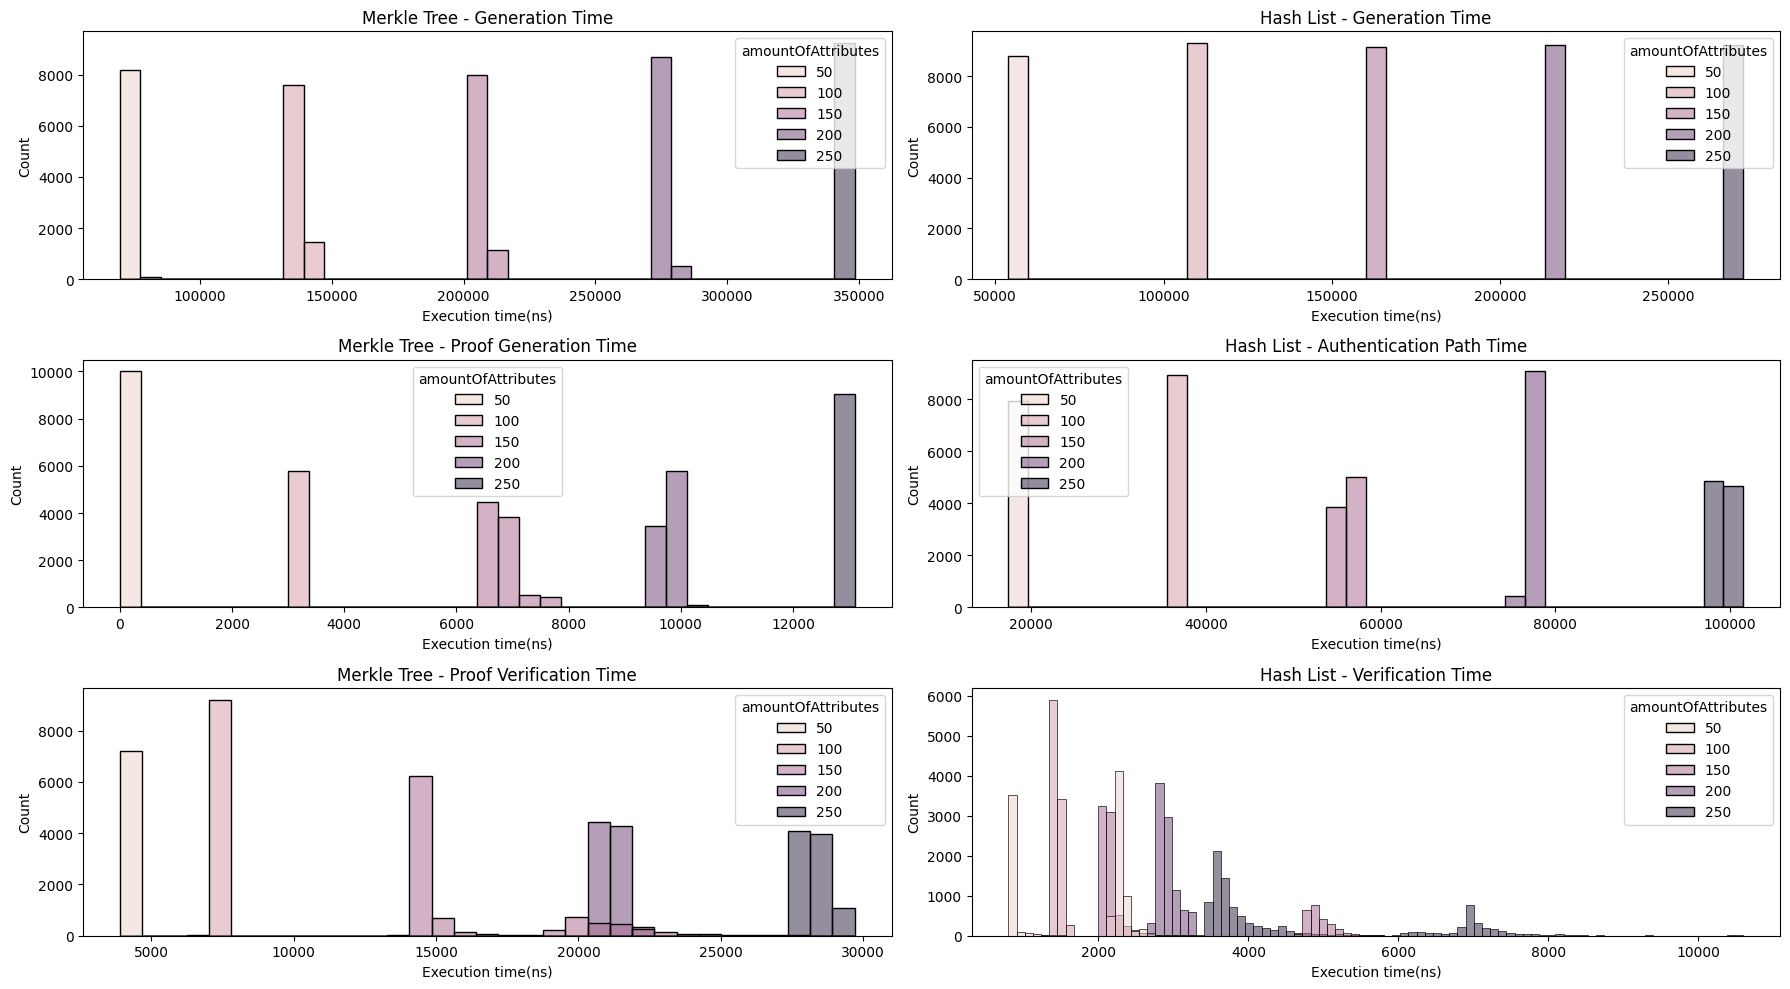

In [161]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

sns.histplot(data=gen_merkle, x="executionTime", hue="amountOfAttributes", ax=axes[0,0])
axes[0,0].set_title("Merkle Tree - Generation Time")
axes[0,0].set_xlabel("Execution time(ns)")

sns.histplot(data=gen_hash, x="executionTime", hue="amountOfAttributes", ax=axes[0,1])
axes[0,1].set_title("Hash List - Generation Time")
axes[0,1].set_xlabel("Execution time(ns)")

sns.histplot(data=proof_merkle, x="executionTime", hue="amountOfAttributes", ax=axes[1,0])
axes[1,0].set_title("Merkle Tree - Proof Generation Time")
axes[1,0].set_xlabel("Execution time(ns)")

sns.histplot(data=proof_hash, x="executionTime", hue="amountOfAttributes", ax=axes[1,1])
axes[1,1].set_title("Hash List - Authentication Path Time")
axes[1,1].set_xlabel("Execution time(ns)")

sns.histplot(data=auth_merkle, x="executionTime", hue="amountOfAttributes", ax=axes[2,0])
axes[2,0].set_title("Merkle Tree - Proof Verification Time")
axes[2,0].set_xlabel("Execution time(ns)")

sns.histplot(data=auth_hash, x="executionTime", hue="amountOfAttributes", ax=axes[2,1])
axes[2,1].set_title("Hash List - Verification Time")
axes[2,1].set_xlabel("Execution time(ns)")

plt.tight_layout()
plt.show()


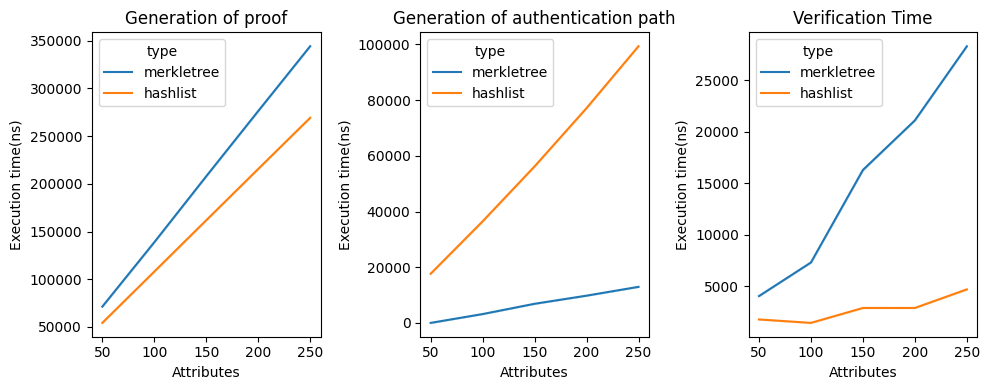

In [162]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
sns.lineplot(data=generation_df, x="amountOfAttributes", y="executionTime", hue="type", ax=axes[0])
axes[0].set_title("Generation of proof")
axes[0].set_xlabel("Attributes")
axes[0].set_ylabel("Execution time(ns)")


sns.lineplot(data=proof_df, x="amountOfAttributes", y="executionTime", hue="type", ax=axes[1])
axes[1].set_title("Generation of authentication path")
axes[1].set_xlabel("Attributes")
axes[1].set_ylabel("Execution time(ns)")

sns.lineplot(data=auth_, x="amountOfAttributes", y="executionTime", hue="type", ax=axes[2])
axes[2].set_title("Verification Time")
axes[2].set_xlabel("Attributes")
axes[2].set_ylabel("Execution time(ns)")


plt.tight_layout()
plt.show()


In [163]:
auth_df

,type,testType,amountOfAttributes,runNo,executionTime
0,merkletree,authPath,50,1032,4200
1,merkletree,authPath,50,1033,4100
2,merkletree,authPath,50,1035,4200
3,merkletree,authPath,50,1036,4100
4,merkletree,authPath,50,1037,4100
...,...,...,...,...,...
93018,hashlist,authPath,250,9996,7300
93019,hashlist,authPath,250,9997,7300
93020,hashlist,authPath,250,9998,7500
93021,hashlist,authPath,250,9999,9100
